# Objectif 

Date de création : 29/05/2026

Illustration du jeu de données 9R : https://ds.iris.edu/mda/9R/?starttime=2022-11-01T00:00:00&endtime=2023-09-01T23:59:59

In [1]:
# %matplotlib ipympl

import os
import sys
import numpy as np
import xarray as xr
import scipy.signal as sp
import matplotlib.pyplot as plt

from matplotlib.colors import LogNorm
from datetime import datetime
from scipy.fft import rfft, rfftfreq
from scipy.signal import find_peaks


sys.path.append(r"C:\Users\baptiste.menetrier\Desktop\devPy\phd")

import source.global_constants as g
from publication.publication_figure import (
    PubFigure,
    LargeFigure,
    SmallFigure,
    color,
    set_subfigures_abc_labels,
)


from source.rtf_mfp.rtf_mfp_plot_utils import plot_sequence_spectrogram
from misc import progression_bar

In [2]:
fig_folder = (
    r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\reseau_9R\img"
)

# Chargement des données 

In [3]:
root_data = (
    r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\reseau_9R\data"
)

In [4]:
# Load data
ds_wav = xr.open_dataset(os.path.join(root_data, "channel_EDH_wav.nc"))
ds_bathy = xr.open_dataset(os.path.join(root_data, "bathy.nc"))
ds_ais = xr.open_dataset(os.path.join(root_data, "ais.nc"))
ds_network_9R = xr.open_dataset(os.path.join(root_data, "9R_network.nc"))


In [5]:
ds_ais

<xarray.Dataset> Size: 4GB
Dimensions:  (mmsi: 1822, time: 267832)
Coordinates:
  * mmsi     (mmsi) uint32 7kB 403536000 403520001 ... 378399000 626079000
  * time     (time) datetime64[ns] 2MB 2022-12-31T23:59:10 ... 2023-01-31T23:...
Data variables:
    lon      (mmsi, time) float32 2GB ...
    lat      (mmsi, time) float32 2GB ...
Attributes:
    network:                  9R
    description:              AIS data for the 9R network area, interpolated ...
    interpolation_time_step:  10.0
    geodesic_frame:           WGS84

In [6]:
ds_bathy

<xarray.Dataset> Size: 12MB
Dimensions:    (lat: 2400, lon: 2400)
Coordinates:
  * lat        (lat) float64 19kB 13.38 13.39 13.39 13.39 ... 23.37 23.37 23.38
  * lon        (lon) float64 19kB -86.75 -86.74 -86.74 ... -76.76 -76.76 -76.75
Data variables:
    elevation  (lat, lon) int16 12MB ...
Attributes:
    description:     Bathymetry data from GEBCO 2021
    geodesic_frame:  WGS84

In [7]:
ds_network_9R

<xarray.Dataset> Size: 1kB
Dimensions:      (receiver_id: 35)
Coordinates:
  * receiver_id  (receiver_id) int64 280B 1 2 3 5 6 7 8 ... 31 33 34 35 37 38 39
Data variables:
    latitude     (receiver_id) float64 280B ...
    longitude    (receiver_id) float64 280B ...
    elevation    (receiver_id) float64 280B ...

# Illustration du jeu de données 

## Position du réseau

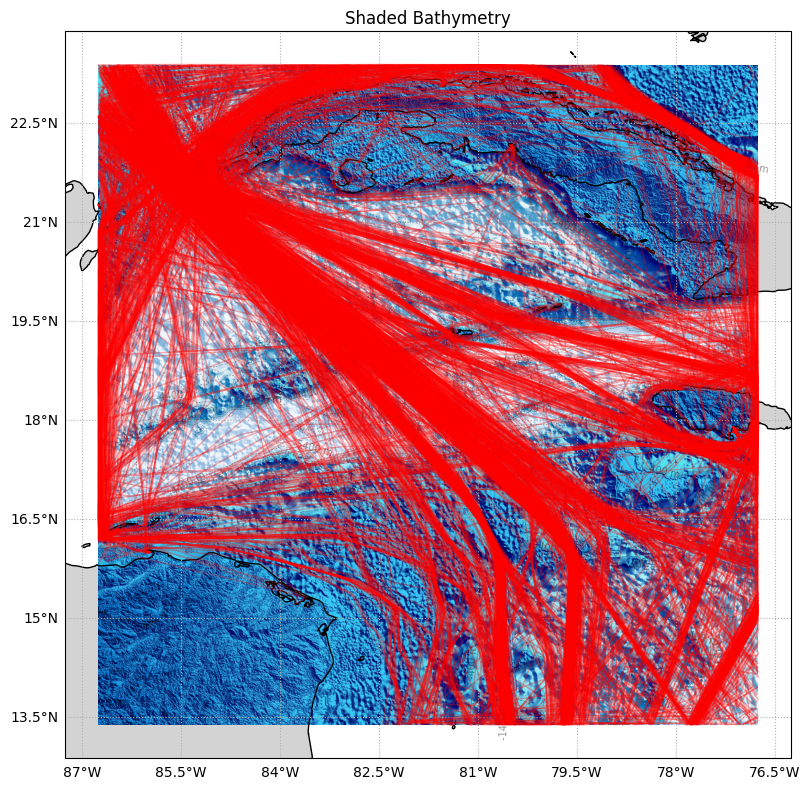

In [8]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ds = xr.open_dataset("bathymetry.nc")

# Extract data
z = ds_bathy["elevation"].values
lon = ds_bathy["lon"].values
lat = ds_bathy["lat"].values

# Hillshade
ls = LightSource(azdeg=315, altdeg=45)  # illumination azimuth  # illumination elevation

# Bathymetry is negative underwater.
# Invert sign so hillshading behaves naturally.
rgb = ls.shade(-z, cmap=plt.cm.Blues_r, vert_exag=5, blend_mode="overlay")

# Figure
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Shaded bathymetry
ax.imshow(
    rgb,
    origin="lower",
    extent=[lon.min(), lon.max(), lat.min(), lat.max()],
    transform=ccrs.PlateCarree(),
)

# Optional depth contours
levels = np.arange(np.floor(z.min() / 100) * 100, 0, 1000)

cs = ax.contour(
    lon,
    lat,
    z,
    levels=levels,
    colors="k",
    linewidths=0.4,
    alpha=0.4,
    transform=ccrs.PlateCarree(),
)

ax.clabel(cs, fmt="%d m", fontsize=7)

# Coastlines
ax.coastlines(resolution="10m", linewidth=1)
ax.add_feature(cfeature.LAND, facecolor="lightgray")

# Grid
gl = ax.gridlines(draw_labels=True, linestyle=":")
gl.top_labels = False
gl.right_labels = False

ax.set_title("Shaded Bathymetry")


rx_lon = ds_network_9R["longitude"].values
rx_lat = ds_network_9R["latitude"].values
rx_id  = ds_network_9R["receiver_id"].values

ax.scatter(
    rx_lon,
    rx_lat,
    s=60,
    c="red",
    edgecolors="white",
    linewidths=1,
    marker="^",
    transform=ccrs.PlateCarree(),
    zorder=10,
    label="Receivers"
)

for lon, lat, rid in zip(rx_lon, rx_lat, rx_id):
    ax.annotate(
        str(rid),
        xy=(lon, lat),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=7,
        bbox=dict(
            boxstyle="round,pad=0.2",
            fc="white",
            ec="none",
            alpha=0.7
        ),
        zorder=11
    )

# for mmsi in ds_ais.mmsi.values:

#     lon_track = ds_ais.lon.sel(mmsi=mmsi).values
#     lat_track = ds_ais.lat.sel(mmsi=mmsi).values

#     mask = np.isfinite(lon_track) & np.isfinite(lat_track)

#     ax.plot(
#         lon_track[mask],
#         lat_track[mask],
#         color="red",
#         linewidth=1,
#         alpha=0.3,
#         transform=ccrs.PlateCarree(),
#         zorder=15,
#     )

plt.tight_layout()
plt.show()

In [10]:
lon_all = ds_ais.lon.values.ravel()
lat_all = ds_ais.lat.values.ravel()

mask = np.isfinite(lon_all) & np.isfinite(lat_all)

lon_all = lon_all[mask]
lat_all = lat_all[mask]

H, xedges, yedges = np.histogram2d(lon_all, lat_all, bins=350)

H[H <= np.nanpercentile(H, 30)] = np.nan

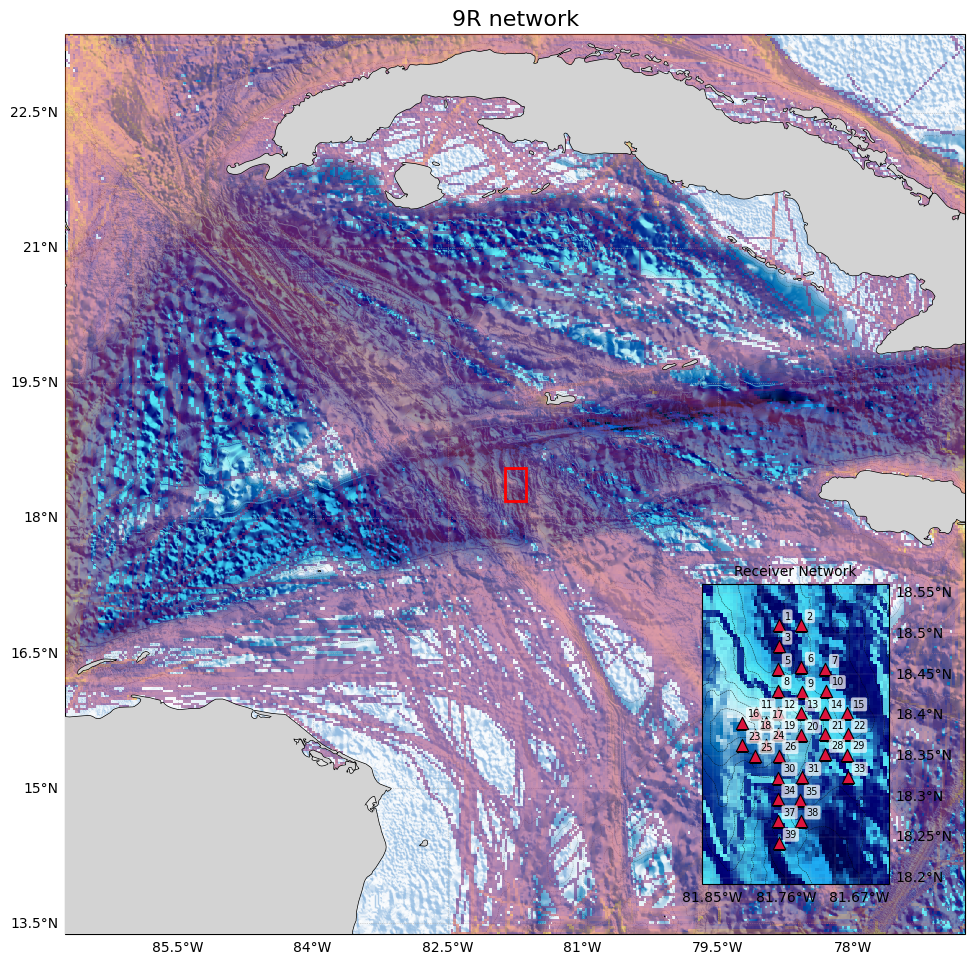

In [13]:
import numpy as np
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from matplotlib.colors import LightSource
from matplotlib.patches import Rectangle

# # =============================================================================
# # INPUT DATA
# # =============================================================================

# Extract data
z = ds_bathy["elevation"].values
lon = ds_bathy["lon"].values
lat = ds_bathy["lat"].values

# Receiver dataset
rx_lon = ds_network_9R["longitude"].values
rx_lat = ds_network_9R["latitude"].values
rx_id = ds_network_9R["receiver_id"].values

# =============================================================================
# DEFINE ZOOM AREA FROM RECEIVER NETWORK
# =============================================================================

pad = 0.05  # degrees

zoom_extent = [
    rx_lon.min() - pad,
    rx_lon.max() + pad,
    rx_lat.min() - pad,
    rx_lat.max() + pad,
]

# =============================================================================
# HILLSHADE
# =============================================================================

ls = LightSource(
    azdeg=315,
    altdeg=45,
)

# Hillshade computed on bathymetry
rgb = ls.shade(
    -z,  # invert bathymetry for proper relief
    cmap=plt.cm.Blues,
    vert_exag=8,
    blend_mode="overlay",
)
# import cmocean

# rgb = ls.shade(-z, cmap=cmocean.cm.deep, vert_exag=8, blend_mode="soft")
# rgb = ls.shade(-z, cmap=cmocean.cm.tempo, vert_exag=8, blend_mode="overlay")


# =============================================================================
# FIGURE
# =============================================================================

fig = plt.figure(figsize=(14, 10))

# -----------------------------------------------------------------------------
# MAIN MAP
# -----------------------------------------------------------------------------

ax = fig.add_axes(
    [0.05, 0.05, 0.90, 0.90],
    projection=ccrs.PlateCarree(),
)

ax.imshow(
    rgb,
    origin="lower",
    extent=[lon.min(), lon.max(), lat.min(), lat.max()],
    transform=ccrs.PlateCarree(),
)

# Bathymetric contours
levels = np.arange(
    np.floor(z.min() / 100) * 100,
    0,
    1000,
)

cs = ax.contour(
    lon,
    lat,
    z,
    levels=levels,
    colors="k",
    linewidths=0.3,
    alpha=0.4,
    transform=ccrs.PlateCarree(),
)


# # Receiver halo
# ax.scatter(
#     rx_lon,
#     rx_lat,
#     s=120,
#     c="white",
#     linewidths=0,
#     transform=ccrs.PlateCarree(),
#     zorder=9,
# )

# # Receiver symbols
# ax.scatter(
#     rx_lon,
#     rx_lat,
#     s=50,
#     c="crimson",
#     marker="^",
#     edgecolors="black",
#     linewidths=0.5,
#     transform=ccrs.PlateCarree(),
#     zorder=10,
# )

# Zoom rectangle
rect = Rectangle(
    (zoom_extent[0], zoom_extent[2]),
    zoom_extent[1] - zoom_extent[0],
    zoom_extent[3] - zoom_extent[2],
    fill=False,
    edgecolor="red",
    linewidth=2,
    transform=ccrs.PlateCarree(),
    zorder=20,
)

ax.add_patch(rect)

# Grid
gl = ax.gridlines(
    draw_labels=True,
    linestyle=":",
    linewidth=0.5,
)

gl.top_labels = False
gl.right_labels = False

ax.set_title(
    # "Bathymetry and Receiver Network",
    "9R network",
    fontsize=16,
)

# for mmsi in ds_ais.mmsi.values[0:100]:

#     lon_track = ds_ais.lon.sel(mmsi=mmsi).values
#     lat_track = ds_ais.lat.sel(mmsi=mmsi).values

#     mask = np.isfinite(lon_track) & np.isfinite(lat_track)

#     ax.plot(
#         lon_track[mask],
#         lat_track[mask],
#         color="red",
#         linewidth=1,
#         alpha=0.3,
#         transform=ccrs.PlateCarree(),
#         zorder=15,
#     )

ax.pcolormesh(
    xedges,
    yedges,
    H.T,
    cmap="inferno",
    norm=LogNorm(vmin=1),
    alpha=0.5,
    transform=ccrs.PlateCarree(),
    zorder=15,
)

# Create mask
land_mask = z >= 0

# Land color (RGB)
land_color = np.array([0.9, 0.9, 0.9])

# Replace land pixels by a uniform color
rgb_land = rgb.copy()
rgb_land[land_mask, :3] = land_color
rgb_land[~land_mask] = np.nan


ax.imshow(
    rgb_land,
    origin="lower",
    extent=[lon.min(), lon.max(), lat.min(), lat.max()],
    transform=ccrs.PlateCarree(),
    zorder=16,
)

# Coastlines and land
ax.coastlines(resolution="10m", linewidth=1, zorder=17)
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=17)


# =============================================================================
# INSET MAP
# =============================================================================

axins = fig.add_axes(
    [0.55, 0.10, 0.30, 0.30],  # left, bottom, width, height
    projection=ccrs.PlateCarree(),
)

# Bathymetry in inset
axins.imshow(
    rgb,
    origin="lower",
    extent=[lon.min(), lon.max(), lat.min(), lat.max()],
    transform=ccrs.PlateCarree(),
)

# Bathymetric contours
levels = np.arange(
    np.floor(z.min() / 100) * 100,
    0,
    500,
)

# Contours
cs = axins.contour(
    lon,
    lat,
    z,
    levels=levels,
    colors="k",
    linewidths=0.3,
    alpha=1,
    transform=ccrs.PlateCarree(),
)

# axins.clabel(cs, fmt="%d m", fontsize=7)


# Receivers
axins.scatter(
    rx_lon,
    rx_lat,
    s=80,
    c="crimson",
    marker="^",
    edgecolors="black",
    linewidths=0.8,
    transform=ccrs.PlateCarree(),
    zorder=40,
)

# Receiver labels
for rid, x, y in zip(rx_id, rx_lon, rx_lat):
    axins.annotate(
        str(rid),
        (x, y),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=7,
        bbox=dict(
            boxstyle="round,pad=0.2",
            fc="white",
            ec="none",
            alpha=0.7,
        ),
        zorder=41,
    )

# Zoom extent
axins.set_extent(zoom_extent)

# Grid
gl2 = axins.gridlines(
    draw_labels=True,
    linestyle=":",
    linewidth=0.3,
)

gl2.top_labels = False
gl2.right_labels = True
gl2.left_labels = False

axins.set_title(
    "Receiver Network",
    fontsize=10,
)

# =============================================================================
# OPTIONAL: CONNECT INSET TO ZOOM RECTANGLE
# =============================================================================

# # Comment this section out if you don't like it

# fig.lines.extend(
#     [
#         plt.Line2D(
#             [0.53, 0.60],
#             [0.60, 0.70],
#             transform=fig.transFigure,
#             color="red",
#             lw=1,
#             alpha=0.7,
#         ),
#         plt.Line2D(
#             [0.53, 0.60],
#             [0.50, 0.55],
#             transform=fig.transFigure,
#             color="red",
#             lw=1,
#             alpha=0.7,
#         ),
#     ]
# )

# =============================================================================

plt.show()

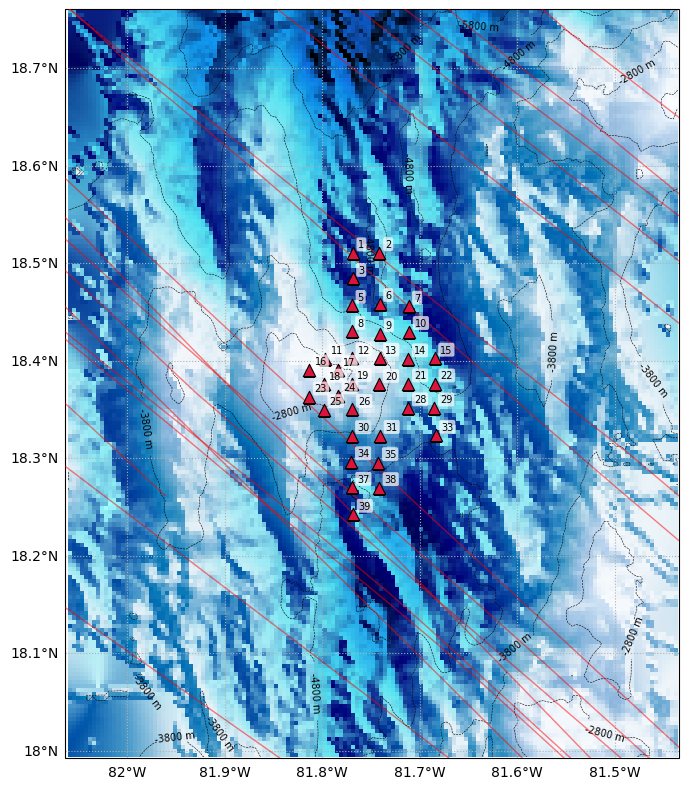

In [25]:
# Extract data

pad = 0.25  # degrees

zoom_extent = [
    rx_lon.min() - pad,
    rx_lon.max() + pad,
    rx_lat.min() - pad,
    rx_lat.max() + pad,
]

bathy_zoom = ds_bathy.sel(
    lon=slice(zoom_extent[0], zoom_extent[1]), lat=slice(zoom_extent[2], zoom_extent[3])
)


z = bathy_zoom["elevation"].values
lon = bathy_zoom["lon"].values
lat = bathy_zoom["lat"].values

# Hillshade
ls = LightSource(azdeg=315, altdeg=45)  # illumination azimuth  # illumination elevation
rgb = ls.shade(-z, cmap=plt.cm.Blues, vert_exag=5, blend_mode="overlay")

# Figure
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())


# Shaded bathymetry
ax.imshow(
    rgb,
    origin="lower",
    extent=[lon.min(), lon.max(), lat.min(), lat.max()],
    transform=ccrs.PlateCarree(),
)

# Optional depth contours
levels = np.arange(np.floor(z.min() / 100) * 100, 0, 1000)

cs = ax.contour(
    lon,
    lat,
    z,
    levels=levels,
    colors="k",
    linewidths=0.4,
    alpha=1,
    transform=ccrs.PlateCarree(),
)

ax.clabel(cs, fmt="%d m", fontsize=7)

# Coastlines
ax.coastlines(resolution="10m", linewidth=1)
ax.add_feature(cfeature.LAND, facecolor="lightgray")

# Grid
gl = ax.gridlines(draw_labels=True, linestyle=":")
gl.top_labels = False
gl.right_labels = False

ax.set_title("")


rx_lon = ds_network_9R["longitude"].values
rx_lat = ds_network_9R["latitude"].values
rx_id = ds_network_9R["receiver_id"].values


# Receivers
ax.scatter(
    rx_lon,
    rx_lat,
    s=80,
    c="crimson",
    marker="^",
    edgecolors="black",
    linewidths=0.8,
    transform=ccrs.PlateCarree(),
    zorder=40,
)

# Receiver labels
for rid, x, y in zip(rx_id, rx_lon, rx_lat):
    ax.annotate(
        str(rid),
        (x, y),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=7,
        bbox=dict(
            boxstyle="round,pad=0.2",
            fc="white",
            ec="none",
            alpha=0.7,
        ),
        zorder=41,
    )


ds_ais_day = ds_ais.sel(
    time="2023-01-02",
)
for mmsi in ds_ais_day.mmsi.values:

    lon_track = ds_ais_day.lon.sel(mmsi=mmsi).values
    lat_track = ds_ais_day.lat.sel(mmsi=mmsi).values

    mask = np.isfinite(lon_track) & np.isfinite(lat_track)

    ax.plot(
        lon_track[mask],
        lat_track[mask],
        color="red",
        linewidth=1,
        alpha=0.5,
        transform=ccrs.PlateCarree(),
        zorder=15,
    )

# Zoom on the area of interest
ax.set_extent(zoom_extent)

plt.tight_layout()
plt.show()

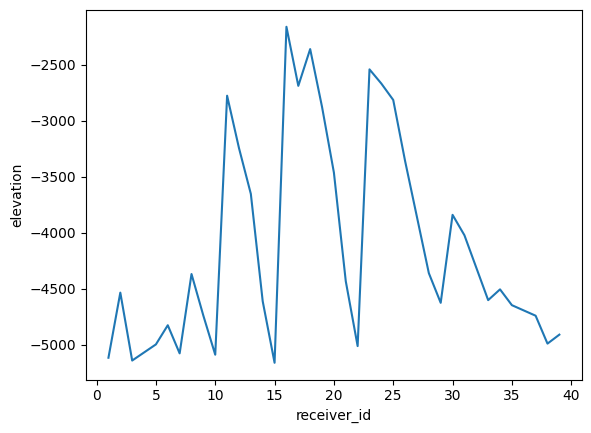

In [12]:
plt.figure()
ds_network_9R.elevation.plot()
